In [ ]:
import os
import torch
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import random

In [2]:
base_dir="/kaggle/input/datasets/kartikmaity/qata-cov19-dataset-segmentation/QaTa-COV19/QaTa-COV19-v2"

train_img_dir = os.path.join(base_dir,"Train Set/Images")
train_mask_dir = os.path.join(base_dir,"Train Set/Ground-truths")

test_img_dir = os.path.join(base_dir,"Test Set/Images")
test_mask_dir = os.path.join(base_dir,"Test Set/Ground-truths")

(490, 488, 3)


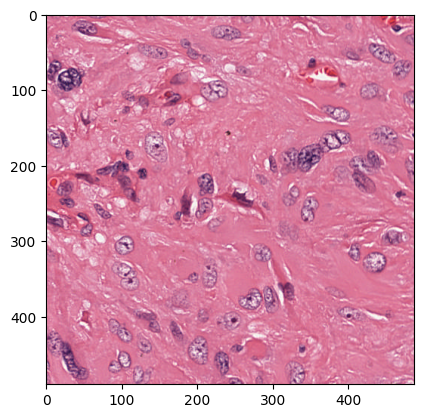

In [3]:
img_sample=cv2.imread(os.path.join(img_dir,"image_01.png"))
# # # i=i.permute(1,2,0).numpy()
img_sample = cv2.cvtColor(img_sample, cv2.COLOR_BGR2RGB)

plt.imshow(img_sample)
print(img_sample.shape)

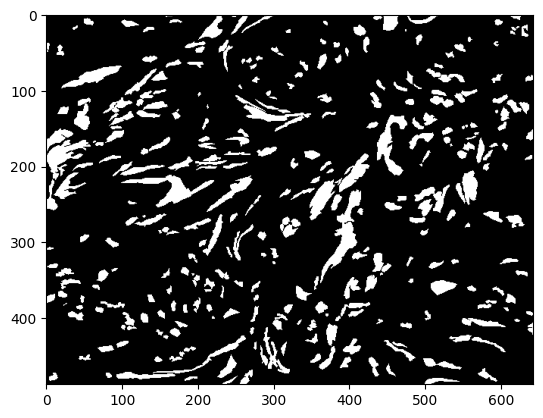

In [4]:
mask_sample=cv2.imread(os.path.join(mask_dir,"image_00.png"))
plt.imshow(mask_sample)

In [5]:
import albumentations as A
from torch.utils.data import Dataset, DataLoader, random_split

class cpm15Dataset(Dataset):
    def __init__(self,img_dir,mask_dir,indices=None, transform=None):
        self.img_dir=img_dir
        self.mask_dir=mask_dir
        self.indices=indices
        self.transform=transform

        self.images= sorted(os.listdir(img_dir))
        self.masks= sorted(os.listdir(mask_dir))

        if indices is not None:
            self.images= [self.images[i] for i in indices]
            self.masks= [self.masks[i] for i in indices]
    def __len__(self):
        return len(self.images)
    def __getitem__(self,idx):
        image_name = self.images[idx]
        img_path=os.path.join(self.img_dir,image_name)
        mask_name = "mask_" + image_name
        mask_path=os.path.join(self.mask_dir, mask_name)

        image= np.array(Image.open(img_path).convert("RGB").resize((256,256)))/255.0
        mask= np.array(Image.open(mask_path).convert("L").resize((256,256)))/255.0
        mask=np.where(mask>0.5, 1 , 0)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        image= torch.tensor(image).permute(2,0,1).float()
        mask=torch.tensor(mask).unsqueeze(0).float()

        return image,mask


In [6]:
# AUGMENTATIONS

train_transform= A.Compose([A.Resize(512,512),
A.RandomCrop(height=512,width=512, always_apply=True),
                           A.HorizontalFlip(p=0.5),
                           A.VerticalFlip(p=0.5),
                           A.RandomRotate90(p=0.5),
                           A.ShiftScaleRotate(shift_limit=0.02, scale_limit=(-0.04,0.04), rotate_limit=(-15,15), p=0.5)
                           ])

val_transform= A.Compose([A.Resize(512,512)])

test_transform=A.Compose([
    A.Resize(512,512)
])


        

/tmp/ipykernel_58/3606764830.py:4: UserWarning: Argument(s) 'always_apply' are not valid for transform RandomCrop
  A.RandomCrop(height=512,width=512, always_apply=True),
/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [7]:
# =============================================================
# Dataset Splitting
# =============================================================

import os
import random
from torch.utils.data import DataLoader

random.seed(42)

# -------------------------------------------------------------
# Paths
# -------------------------------------------------------------

train_img_dir = os.path.join(base_dir,"Train Set/Images")
train_mask_dir = os.path.join(base_dir,"Train Set/Ground-truths")

test_img_dir = os.path.join(base_dir,"Test Set/Images")
test_mask_dir = os.path.join(base_dir,"Test Set/Ground-truths")


# -------------------------------------------------------------
# Get image files
# -------------------------------------------------------------

train_images = sorted(os.listdir(train_img_dir))
test_images = sorted(os.listdir(test_img_dir))

n_train_total = len(train_images)
n_test_total = len(test_images)

print(f"Original train images : {n_train_total}")
print(f"Original test images  : {n_test_total}")


# -------------------------------------------------------------
# Split ONLY the original training data
# 80% → Train
# 20% → Validation
# -------------------------------------------------------------

indices = list(range(n_train_total))
random.shuffle(indices)

train_end = int(0.8 * n_train_total)

train_indices = indices[:train_end]
val_indices = indices[train_end:]


# -------------------------------------------------------------
# Test indices
# Keep the ORIGINAL test set untouched
# -------------------------------------------------------------

test_indices = list(range(n_test_total))


# -------------------------------------------------------------
# Create datasets
# -------------------------------------------------------------

train_dataset = cpm15Dataset(
    train_img_dir,
    train_mask_dir,
    train_indices,
    train_transform
)

val_dataset = cpm15Dataset(
    train_img_dir,
    train_mask_dir,
    val_indices,
    val_transform
)

test_dataset = cpm15Dataset(
    test_img_dir,
    test_mask_dir,
    test_indices,
    test_transform
)


# -------------------------------------------------------------
# DataLoaders
# -------------------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False
)


# -------------------------------------------------------------
# Summary
# -------------------------------------------------------------

print("\n✅ Dataset loaded successfully!")

print(
    f"Train: {len(train_dataset)} | "
    f"Validation: {len(val_dataset)} | "
    f"Test: {len(test_dataset)}"
)

print(
    f"Total used: "
    f"{len(train_dataset) + len(val_dataset) + len(test_dataset)}"
)

15
✅ Dataset loaded successfully!
Total: 15 | Train: 10 | Val: 3 | Test: 2


Unet++ Implementation

In [8]:
# Unet++ Implementation
import torch
import torch.nn as nn
from torchinfo import summary

class DoubleConv(nn.Module):
    def __init__(self,in_channels,out_channels):
        super().__init__()
        self.double_conv=nn.Sequential(
            nn.Conv2d(in_channels,out_channels,3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels,3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self,x):
        return self.double_conv(x)


class Unet_plus_plus(nn.Module):
    def __init__(self,n_channels=3, n_classes=1):
        super().__init__()
        #Encoder
        self.enc1= DoubleConv(n_channels,64)
        self.enc2=DoubleConv(64,128)
        self.enc3=DoubleConv(128,256)
        self.enc4=DoubleConv(256,512)

        #Max Pooling
        self.pool=nn.MaxPool2d(2)

        #BottleNeck
        self.bottleNeck=DoubleConv(512,1024)

        #Upsampling
        self.up_1024_512= nn.ConvTranspose2d(1024,512,2, stride=2)        
        self.up_512_256=nn.ConvTranspose2d(512,256,2,stride=2)        
        self.up_256_128=nn.ConvTranspose2d(256,128,2,stride=2)        
        self.up_128_64=nn.ConvTranspose2d(128,64,2,stride=2)

        self.dec1=DoubleConv(1024,512)
        self.dec2=DoubleConv(512,256)
        self.dec3=DoubleConv(256,128)
        self.dec4=DoubleConv(128,64)
		
        self.finalConv=nn.Conv2d(64,n_classes,1)

    def forward(self,x):
        c0_0=self.enc1(x)
        c1_0 = self.enc2(self.pool(c0_0))
        c2_0= self.enc3(self.pool(c1_0))
        c3_0= self.enc4(self.pool(c2_0))
        b= self.bottleNeck(self.pool(c3_0))

        

        c3_1=self.up_1024_512(b)
        c3_1 =torch.cat([c3_0, c3_1], dim=1)
        c3_1=self.dec1(c3_1)

        c2_1=self.up_512_256(c3_0)
        c2_1=torch.cat([c2_0,c2_1], dim=1)
        c2_1=self.dec2(c2_1)

        c2_2=self.up_512_256(c3_1)
        c2_2=torch.cat([c2_1,c2_2],dim=1)
        c2_2=self.dec2(c2_2)

        c1_1=self.up_256_128(c2_0)
        c1_1=torch.cat([c1_0,c1_1], dim=1)
        c1_1=self.dec3(c1_1)

        c1_2=self.up_256_128(c2_1)
        c1_2=torch.cat([c1_2,c1_1], dim=1)
        c1_2=self.dec3(c1_2)

        c1_3=self.up_256_128(c2_2)
        c1_3=torch.cat([c1_2,c1_3],dim=1)
        c1_3=self.dec3(c1_3)

        c0_1=self.up_128_64(c1_0)
        c0_1=torch.cat([c0_1,c0_0], dim=1)
        c0_1=self.dec4(c0_1)

        c0_2=self.up_128_64(c1_1)
        c0_2=torch.cat([c0_2,c0_1], dim=1)
        c0_2=self.dec4(c0_2)

        c0_3=self.up_128_64(c1_2)
        c0_3=torch.cat([c0_3,c0_2], dim=1)
        c0_3=self.dec4(c0_3)

        c0_4=self.up_128_64(c1_3)
        c0_4=torch.cat([c0_4,c0_3],dim=1)
        c0_4=self.dec4(c0_4)

        out1 = torch.sigmoid(self.finalConv(c0_1))
        out2 = torch.sigmoid(self.finalConv(c0_2))
        out3 = torch.sigmoid(self.finalConv(c0_3))
        out4 = torch.sigmoid(self.finalConv(c0_4))

        return [out1, out2, out3, out4]   # loss = sum/avg over all 4
    
# =============================================================
# Print Model Summary
# =============================================================
if __name__ == "__main__":
    model = Unet_plus_plus(n_channels=3, n_classes=1)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)

    print("\n================= MODEL SUMMARY =================\n")
    print(summary(model, input_size=(4, 3, 256, 256)))


        




================= MODEL SUMMARY =================

Layer (type:depth-idx)                   Output Shape              Param #
Unet_plus_plus                           [4, 1, 256, 256]          --
├─DoubleConv: 1-1                        [4, 64, 256, 256]         --
│    └─Sequential: 2-1                   [4, 64, 256, 256]         --
│    │    └─Conv2d: 3-1                  [4, 64, 256, 256]         1,792
│    │    └─BatchNorm2d: 3-2             [4, 64, 256, 256]         128
│    │    └─ReLU: 3-3                    [4, 64, 256, 256]         --
│    │    └─Conv2d: 3-4                  [4, 64, 256, 256]         36,928
│    │    └─BatchNorm2d: 3-5             [4, 64, 256, 256]         128
│    │    └─ReLU: 3-6                    [4, 64, 256, 256]         --
├─MaxPool2d: 1-2                         [4, 64, 128, 128]         --
├─DoubleConv: 1-3                        [4, 128, 128, 128]        --
│    └─Sequential: 2-2                   [4, 128, 128, 128]        --
│    │    └─Conv2d: 3-7 

Epoch 1/100 [Val]: 100%|██████████| 3/3 [00:00<00:00,  4.90it/s]



Epoch 1/100
Train Loss: 0.7263 | Val Loss: 0.7405
Train Dice: 0.2885 | Val Dice: 0.2323
Train IoU : 0.1971 | Val IoU : 0.1434
✅ Best model saved (Epoch 1, Val Loss 0.7405)


Epoch 2/100 [Val]: 100%|██████████| 3/3 [00:00<00:00,  5.50it/s]



Epoch 2/100
Train Loss: 0.6364 | Val Loss: 0.6974
Train Dice: 0.3599 | Val Dice: 0.2212
Train IoU : 0.3612 | Val IoU : 0.0007
✅ Best model saved (Epoch 2, Val Loss 0.6974)


Epoch 3/100 [Val]: 100%|██████████| 3/3 [00:00<00:00,  5.43it/s]


...


Epoch 98/100
Train Loss: 0.2663 | Val Loss: 0.3599
Train Dice: 0.6644 | Val Dice: 0.5846
Train IoU : 0.7901 | Val IoU : 0.6030
✅ Best model saved (Epoch 98, Val Loss 0.3599)


Epoch 99/100 [Val]: 100%|██████████| 3/3 [00:00<00:00,  5.07it/s]



Epoch 99/100
Train Loss: 0.2622 | Val Loss: 0.3921
Train Dice: 0.6792 | Val Dice: 0.5510
Train IoU : 0.7861 | Val IoU : 0.5430


Epoch 100/100 [Val]: 100%|██████████| 3/3 [00:00<00:00,  5.02it/s]



Epoch 100/100
Train Loss: 0.2677 | Val Loss: 0.3618
Train Dice: 0.6636 | Val Dice: 0.5855
Train IoU : 0.7794 | Val IoU : 0.6063

🎉 Training Completed!
🏆 Best Epoch: 98
✔ Best Val Loss: 0.3599


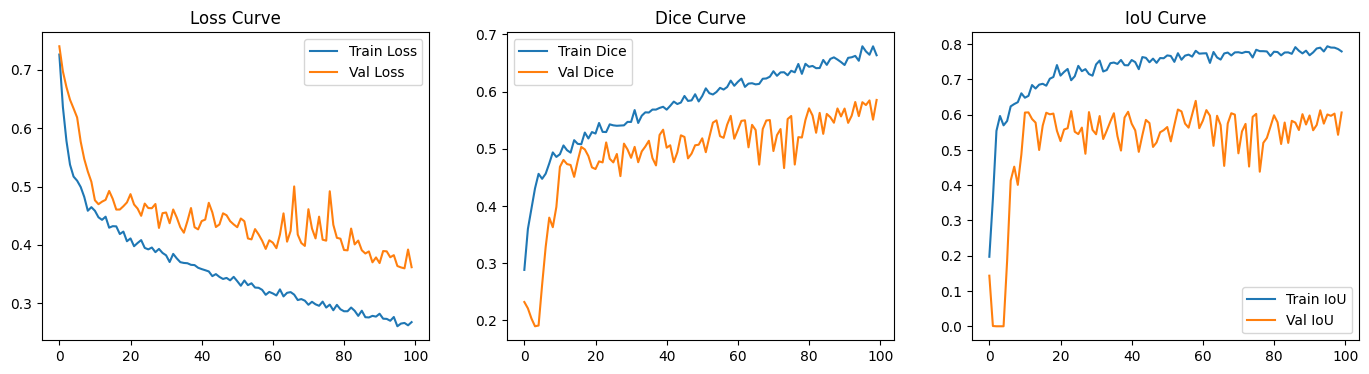

In [9]:
# =============================================================
# LOSS + METRICS
# =============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import copy
import matplotlib.pyplot as plt


# BCE + Dice Loss
class BCEDiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCELoss()

    def forward(self, preds, targets):
        bce_loss = self.bce(preds, targets)

        preds_f = preds.view(-1)
        targets_f = targets.view(-1)
        inter = (preds_f * targets_f).sum()
        dice_loss = 1 - (2 * inter + self.smooth) / \
                        (preds_f.sum() + targets_f.sum() + self.smooth)

        return 0.5 * bce_loss + 0.5 * dice_loss


# Dice Metric
def dice_coef(y_true, y_pred, smooth=1e-5):
    y_true_f = y_true.view(-1)
    y_pred_f = y_pred.view(-1)
    inter = (y_true_f * y_pred_f).sum()
    return (2. * inter + smooth) / (y_true_f.sum() + y_pred_f.sum() + smooth)


# IoU Metric
def iou_score(preds, masks, threshold=0.5, eps=1e-6):
    preds_bin = (preds > threshold).float()
    masks_bin = (masks > threshold).float()

    inter = (preds_bin * masks_bin).sum().item()
    union = preds_bin.sum().item() + masks_bin.sum().item() - inter

    return inter / (union + eps)



def deep_supervision_loss(outputs, targets, criterion, weights=None):
    if weights is None:
        weights = [1.0] * len(outputs)   # equal weighting = simple average
    loss = sum(w * criterion(out, targets) for out, w in zip(outputs, weights))
    return loss / sum(weights)
# =============================================================
# TRAINING LOOP
# =============================================================
def train_model(model, train_loader, val_loader, epochs=50):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)

    criterion = BCEDiceLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    # Tracking curves
    train_losses, val_losses = [], []
    train_dice_scores, val_dice_scores = [], []
    train_iou_scores, val_iou_scores = [], []

    best_val_loss = float("inf")
    best_epoch = 0
    best_model_weights = None

    for epoch in range(epochs):

        # ------------------ TRAIN ------------------
        model.train()
        train_loss = train_dice = train_iou = 0

        for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            images, masks = images.to(device), masks.to(device)

            outputs = model(images)
            loss = deep_supervision_loss(outputs, masks, criterion)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            final_pred = outputs[-1]
            train_loss += loss.item()
            train_dice += dice_coef(masks, final_pred).item()
            train_iou += iou_score(final_pred, masks)

        # ------------------ VALIDATION ------------------
        model.eval()
        val_loss = val_dice = val_iou = 0

        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                images, masks = images.to(device), masks.to(device)

                outputs = model(images)
                loss = deep_supervision_loss(outputs, masks, criterion)
                final_pred = outputs[-1]
                val_loss += loss.item()
                val_dice += dice_coef(masks, final_pred).item()
                val_iou += iou_score(final_pred, masks)

        # ------------------ AVERAGES ------------------
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss   = val_loss / len(val_loader)
        avg_train_dice = train_dice / len(train_loader)
        avg_val_dice   = val_dice / len(val_loader)
        avg_train_iou  = train_iou / len(train_loader)
        avg_val_iou    = val_iou / len(val_loader)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_dice_scores.append(avg_train_dice)
        val_dice_scores.append(avg_val_dice)
        train_iou_scores.append(avg_train_iou)
        val_iou_scores.append(avg_val_iou)

        # ------------------ PRINT ------------------
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        print(f"Train Dice: {avg_train_dice:.4f} | Val Dice: {avg_val_dice:.4f}")
        print(f"Train IoU : {avg_train_iou:.4f} | Val IoU : {avg_val_iou:.4f}")

        # ------------------ SAVE BEST ------------------
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch + 1
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), "best_unet_monu.pth")
            print(f"✅ Best model saved (Epoch {epoch+1}, Val Loss {best_val_loss:.4f})")

    # ------------------ LOAD BEST MODEL ------------------
    model.load_state_dict(best_model_weights)

    print("\n🎉 Training Completed!")
    print(f"🏆 Best Epoch: {best_epoch}")
    print(f"✔ Best Val Loss: {best_val_loss:.4f}")

    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_dice": train_dice_scores,
        "val_dice": val_dice_scores,
        "train_iou": train_iou_scores,
        "val_iou": val_iou_scores,
    }


# =============================================================
# PLOTTING FUNCTION
# =============================================================
def plot_training(history):
    plt.figure(figsize=(17, 4))

    # Loss
    plt.subplot(1, 3, 1)
    plt.plot(history["train_losses"], label="Train Loss")
    plt.plot(history["val_losses"], label="Val Loss")
    plt.title("Loss Curve")
    plt.legend()

    # Dice
    plt.subplot(1, 3, 2)
    plt.plot(history["train_dice"], label="Train Dice")
    plt.plot(history["val_dice"], label="Val Dice")
    plt.title("Dice Curve")
    plt.legend()

    # IoU
    plt.subplot(1, 3, 3)
    plt.plot(history["train_iou"], label="Train IoU")
    plt.plot(history["val_iou"], label="Val IoU")
    plt.title("IoU Curve")
    plt.legend()

    plt.show()

model = Unet_plus_plus().to(device)
history = train_model(model, train_loader, val_loader, epochs=100)
plot_training(history)

📥 Loading best model...
🧪 Evaluating on test set...


Evaluating Test Set: 100%|██████████| 2/2 [00:00<00:00,  4.14it/s]



🎯 TEST SET EVALUATION
✅ Dice Coefficient: 0.6807
✅ IoU (Jaccard):    0.5412

📊 Generating visualizations...


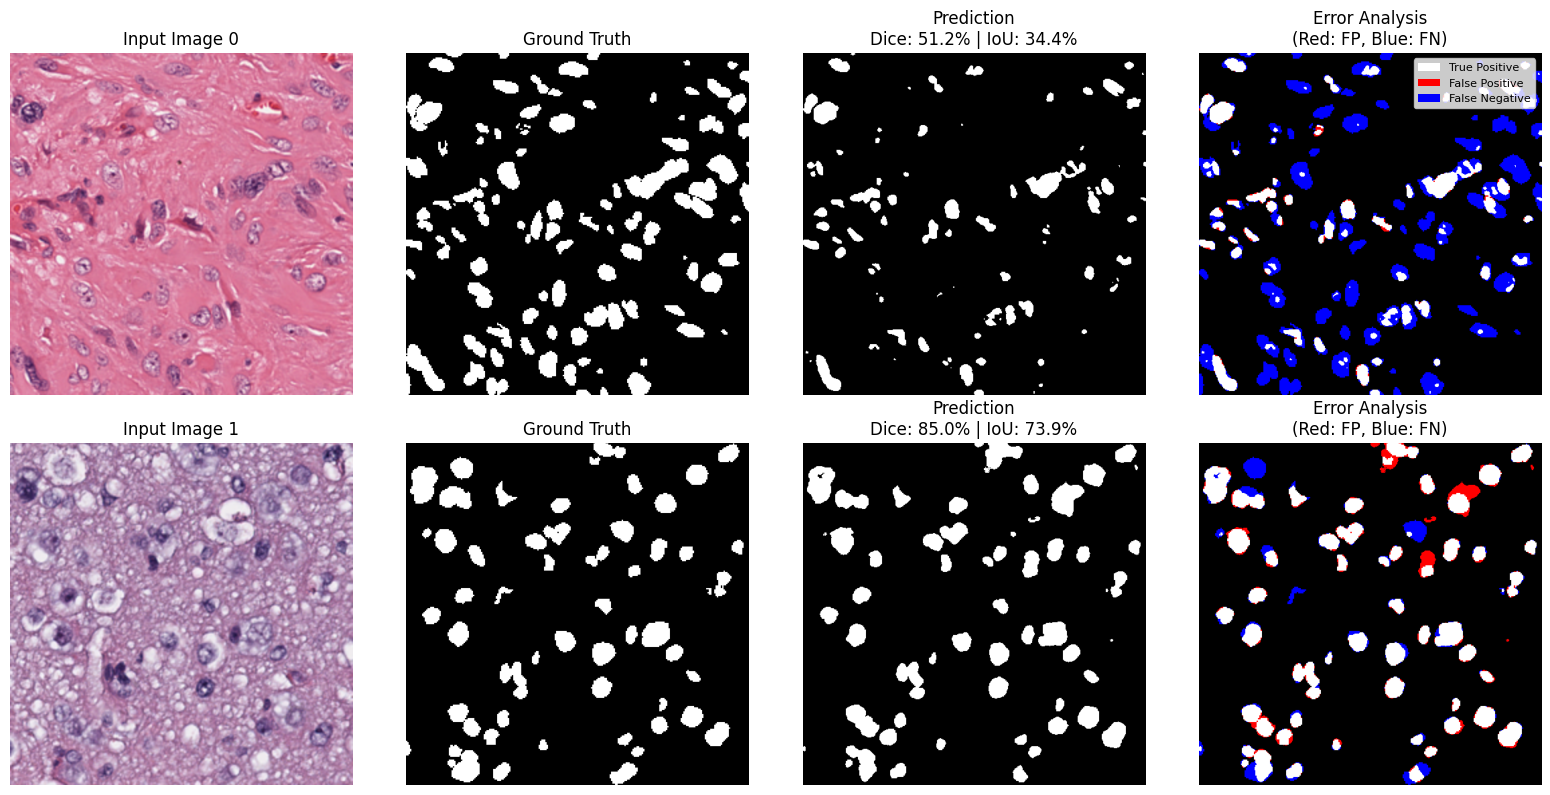


🎉 Evaluation completed successfully!


In [10]:
# =============================================================
# Simplified Test Evaluation (Only Dice and IoU)
# =============================================================

import numpy as np

def iou_coef(y_true, y_pred, smooth=1e-5):
    """
    Intersection over Union (IoU) metric for binary masks.
    """
    y_true_f = y_true.view(-1)
    y_pred_f = y_pred.view(-1)
    intersection = (y_true_f * y_pred_f).sum()
    union = y_true_f.sum() + y_pred_f.sum() - intersection
    return (intersection + smooth) / (union + smooth)

# Load the best model
print("📥 Loading best model...")
model.load_state_dict(torch.load("best_unet_monu.pth", map_location=device))
model.eval()

# Initialize accumulators for metrics
test_dice, test_iou = 0, 0

print("🧪 Evaluating on test set...")

# Loop through test data
with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="Evaluating Test Set"):
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)          # list of 4 tensors
        preds = outputs[-1]              # use the final, most-refined head (c0_4)
        preds_bin = (preds > 0.5).float()

        test_dice += dice_coef(masks, preds_bin).item()
        test_iou += iou_coef(masks, preds_bin).item()

# Average metrics
num_batches = len(test_loader)
avg_test_dice = test_dice / num_batches
avg_test_iou = test_iou / num_batches

# Print simplified results
print("\n" + "="*40)
print("🎯 TEST SET EVALUATION")
print("="*40)
print(f"✅ Dice Coefficient: {avg_test_dice:.4f}")
print(f"✅ IoU (Jaccard):    {avg_test_iou:.4f}")
print("="*40)

# =============================================================
# Simplified Visualization (Only Dice and IoU)
# =============================================================

def dice_coef_single(y_true, y_pred, smooth=1e-5):
    """Compute Dice coefficient for one pair of masks"""
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    intersection = np.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (np.sum(y_true_f) + np.sum(y_pred_f) + smooth)

def iou_coef_single(y_true, y_pred, smooth=1e-5):
    """Compute IoU for one pair of masks"""
    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection
    return intersection / (union + smooth)

def visualize_predictions_simple(model, dataset, num_samples=5, threshold=0.5):

    num_samples = min(num_samples, len(dataset))

    indices = random.sample(range(len(dataset)), num_samples)

    fig, axes = plt.subplots(
        num_samples, 4,
        figsize=(16, num_samples * 4)
    )

    
    
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i, idx in enumerate(indices):
        image, mask = dataset[idx]

        with torch.no_grad():
            outputs = model(image.unsqueeze(0).to(device))
            pred_prob = outputs[-1].cpu().squeeze().numpy()   # use the final, most-refined head

        pred_mask = (pred_prob > threshold).astype(np.uint8)
        true_mask = mask.squeeze().numpy().astype(np.uint8)
        
        # Compute metrics
        dice_score = dice_coef_single(true_mask, pred_mask) * 100
        iou_score = iou_coef_single(true_mask, pred_mask) * 100
        
        # Create error map (FP: red, FN: blue, TP: white, TN: black)
        error_map = np.zeros((*true_mask.shape, 3), dtype=np.uint8)
        true_positive = (true_mask == 1) & (pred_mask == 1)
        false_positive = (true_mask == 0) & (pred_mask == 1)
        false_negative = (true_mask == 1) & (pred_mask == 0)
        
        error_map[true_positive] = [255, 255, 255]  # White for TP
        error_map[false_positive] = [255, 0, 0]     # Red for FP
        error_map[false_negative] = [0, 0, 255]     # Blue for FN

        # Plot 1: Original Image
        axes[i, 0].imshow(image.permute(1, 2, 0) if image.shape[0] == 3 else image.squeeze(), cmap='gray')
        axes[i, 0].set_title(f"Input Image {idx}")
        axes[i, 0].axis("off")
        
        # Plot 2: Ground Truth
        axes[i, 1].imshow(true_mask, cmap="gray")
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")
        
        # Plot 3: Predicted Mask
        axes[i, 2].imshow(pred_mask, cmap="gray")
        axes[i, 2].set_title(f"Prediction\nDice: {dice_score:.1f}% | IoU: {iou_score:.1f}%")
        axes[i, 2].axis("off")
        
        # Plot 4: Error Analysis
        axes[i, 3].imshow(error_map)
        axes[i, 3].set_title("Error Analysis\n(Red: FP, Blue: FN)")
        axes[i, 3].axis("off")
        
        # Add legend for error map (only for first row)
        if i == 0:
            from matplotlib.patches import Patch
            legend_elements = [
                Patch(facecolor='white', label='True Positive'),
                Patch(facecolor='red', label='False Positive'),
                Patch(facecolor='blue', label='False Negative')
            ]
            axes[i, 3].legend(handles=legend_elements, loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.show()
    
    return indices

# Run simplified visualization
print("\n📊 Generating visualizations...")
sampled_indices = visualize_predictions_simple(model, test_dataset, num_samples=5)

print("\n🎉 Evaluation completed successfully!")
